In [2]:
from pathlib import Path
import sys

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "src").exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(ROOT)
from src.Orchestration.helpers import (
    fetch_direct_child_runs
)

/Users/kingmopser/BachelorThesis/BachelorsThesisCode


/Users/kingmopser/BachelorThesis/BachelorsThesisCode/.pixi/envs/default/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### fetching datasets

In [3]:
df, exp_name = fetch_direct_child_runs("2", "7e99f7fdc8a44f1b9461c3c1bdc6ec46")
print(exp_name)
print(df.shape)

df[['metrics.RMSE', 'metrics.Negative_log_likelihood',
       'metrics.Mean_Winkler_Score', 'metrics.Winkler_Coverage']]

Experiment_Dataset_miami_housing
(64, 30)


,metrics.RMSE,metrics.Negative_log_likelihood,metrics.Mean_Winkler_Score,metrics.Winkler_Coverage
0,0.328707,-0.596145,0.909036,0.912432
1,0.311941,-0.661759,0.844207,0.911978
2,0.309763,-0.636511,0.843236,0.884755
3,0.323370,-0.622101,0.895944,0.915608
4,0.311858,-0.673819,0.841651,0.920145
...,...,...,...,...
59,0.309314,-0.659286,0.840535,0.906987
60,0.305447,-0.642089,0.845099,0.897459
61,0.306867,-0.628098,0.852786,0.899728
62,0.317635,-0.634833,0.866645,0.902450


#### 1x4 Heatmap

In [ ]:
run_specs = [
    {
        "dataset": "fiat500",
        "experiment_id": "5",
        "run_id": "425666d19b9c4027a930589b8a6c63f1",
    },
    {
        "dataset": "healthcare_insurance",
        "experiment_id": "3",
        "run_id": "4a553a4264b54f3fb6b43216d4d7d444",
    },
    {
        "dataset": "wine_quality",
        "experiment_id": "4",
        "run_id": "c963c22d0c7b4f13a6ee0dc353b3ba1c",
    },
    {
        "dataset": "miami_housing",
        "experiment_id": "2",
        "run_id": "7e99f7fdc8a44f1b9461c3c1bdc6ec46",
    },
]



In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.Orchestration.helpers import fetch_direct_child_runs

architectures = ["[16, 16]", "[32, 32]", "[32, 32, 32]", "[16, 16, 16, 16]"]
baseline_arch = "[16, 16]"



rows = []

for spec in run_specs:
    df, exp_name = fetch_direct_child_runs(
        experiment_id=spec["experiment_id"],
        run_id=spec["run_id"],
    )

    work = df[[
        "params.hidden_layers",
        "metrics.Negative_log_likelihood",
    ]].copy()

    work = work.rename(columns={
        "params.hidden_layers": "architecture",
        "metrics.Negative_log_likelihood": "nll",
    })

    work["architecture"] = work["architecture"].astype(str)
    work = work[work["architecture"].isin(architectures)]

    summary = (
        work.groupby("architecture", as_index=False)["nll"]
        .mean()
    )

    summary["architecture"] = pd.Categorical(
        summary["architecture"],
        categories=architectures,
        ordered=True,
    )
    summary = summary.sort_values("architecture")

    baseline_value = summary.loc[
        summary["architecture"] == baseline_arch, "nll"
    ].iloc[0]

    # NLL: lower is better, so positive = improvement
    summary["improvement_pct"] = (
        (baseline_value - summary["nll"]) / abs(baseline_value)
    ) * 100

    row = (
        summary.set_index("architecture")["improvement_pct"]
        .reindex(architectures)
        .rename(spec["dataset"])
    )
    rows.append(row)

heatmap_df = pd.DataFrame(rows)

print(heatmap_df)



plt.style.use("seaborn-v0_8-white")
sns.set_context("paper", font_scale=1.2)

fig, ax = plt.subplots(figsize=(9, 5.5))

limit = np.nanmax(np.abs(heatmap_df.values))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    vmin=-limit,
    vmax=limit,
    linewidths=0.8,
    linecolor="black",
    cbar_kws={"label": "% Improvement (positive = better)"},
    ax=ax,
)

ax.set_title(
    "Effect of Architecture Depth on NLL (% Improvement vs [16, 16])",
    fontsize=14,
    fontweight="bold",
    pad=12,
)
ax.set_xlabel("Network Architecture", fontweight="bold", labelpad=10)
ax.set_ylabel("Dataset", fontweight="bold", labelpad=10)
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("heatmap_nll_all_datasets.pdf", format="pdf", bbox_inches="tight")
plt.show()

#### 4x4 Heatmap

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.Orchestration.helpers import fetch_direct_child_runs

architectures = ["[16, 16]", "[32, 32]", "[32, 32, 32]", "[16, 16, 16, 16]"]
baseline_arch = "[16, 16]"
run_specs = [
    {
        "dataset": "fiat500",
        "experiment_id": "5",
        "run_id": "425666d19b9c4027a930589b8a6c63f1",
    },
    {
        "dataset": "healthcare_insurance",
        "experiment_id": "3",
        "run_id": "4a553a4264b54f3fb6b43216d4d7d444",
    },
    {
        "dataset": "wine_quality",
        "experiment_id": "4",
        "run_id": "c963c22d0c7b4f13a6ee0dc353b3ba1c",
    },
    {
        "dataset": "miami_housing",
        "experiment_id": "2",
        "run_id": "7e99f7fdc8a44f1b9461c3c1bdc6ec46",
    },
]

metric_specs = {
    "RMSE": {
        "column": "metrics.RMSE",
        "lower_is_better": True,
    },
    "NLL": {
        "column": "metrics.Negative_log_likelihood",
        "lower_is_better": True,
    },
    "WinklerScore": {
        "column": "metrics.Mean_Winkler_Score",
        "lower_is_better": True,
    },
}

heatmap_data = {metric_name: [] for metric_name in metric_specs}

for spec in run_specs:
    df, exp_name = fetch_direct_child_runs(
        experiment_id=spec["experiment_id"],
        run_id=spec["run_id"],
    )

    for metric_name, metric_info in metric_specs.items():
        work = df[[
            "params.hidden_layers",
            metric_info["column"],
        ]].copy()

        work = work.rename(columns={
            "params.hidden_layers": "architecture",
            metric_info["column"]: "metric_value",
        })

        work["architecture"] = work["architecture"].astype(str)
        work = work[work["architecture"].isin(architectures)]

        summary = (
            work.groupby("architecture", as_index=False)["metric_value"]
            .mean()
        )

        summary["architecture"] = pd.Categorical(
            summary["architecture"],
            categories=architectures,
            ordered=True,
        )
        summary = summary.sort_values("architecture")

        baseline_value = summary.loc[
            summary["architecture"] == baseline_arch, "metric_value"
        ].iloc[0]

        if metric_info["lower_is_better"]:
            summary["improvement_pct"] = (
                (baseline_value - summary["metric_value"]) / abs(baseline_value)
            ) * 100
        else:
            summary["improvement_pct"] = (
                (summary["metric_value"] - baseline_value) / abs(baseline_value)
            ) * 100

        row = (
            summary.set_index("architecture")["improvement_pct"]
            .reindex(architectures)
            .rename(spec["dataset"])
        )

        heatmap_data[metric_name].append(row)

heatmap_dfs = {
    metric_name: pd.DataFrame(rows)
    for metric_name, rows in heatmap_data.items()
}

for metric_name, df_metric in heatmap_dfs.items():
    print(f"\n{metric_name}")
    print(df_metric)
    
    
plt.style.use("seaborn-v0_8-white")
sns.set_context("paper", font_scale=1.15)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

# 1. Define hard limits for each metric to prevent outlier washout!
metric_limits = {
    "RMSE": 10,           # Caps color scale at ±10%
    "NLL": 100,           # Caps color scale at ±100% (forces that -95623 to just be max red)
    "WinklerScore": 15    # Caps color scale at ±15%
}

for ax, (metric_name, df_metric) in zip(axes, heatmap_dfs.items()):
    
    # 2. Fetch the hardcoded limit instead of dynamically calculating it
    limit = metric_limits.get(metric_name, 100)

    sns.heatmap(
        df_metric,
        annot=True,
        fmt=".2f",
        cmap="vlag_r",    # 3. Add '_r' to reverse it! (Blue = Better, Red = Worse)
        center=0,
        vmin=-limit,      # Apply the bottom cap
        vmax=limit,       # Apply the top cap
        linewidths=0.8,
        linecolor="black",
        cbar_kws={"label": "% Improvement (positive = better)"},
        ax=ax,
    )

    ax.set_title(metric_name, fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("Network Architecture", fontweight="bold", labelpad=10)
    ax.set_ylabel("Dataset" if ax is axes[0] else "", fontweight="bold", labelpad=10)
    
    # Align the x-axis text so it doesn't overlap
    ax.set_xticks(np.arange(len(architectures)) + 0.5)
    ax.set_xticklabels(architectures, rotation=35, ha="right")
    ax.tick_params(axis="y", rotation=0)

fig.suptitle(
    "Effect of Architecture Depth on Predictive Performance\n(% Improvement vs [16, 16])",
    fontsize=15,
    fontweight="bold",
    y=1.05,
)

plt.tight_layout()
plt.savefig("heatmaps_architecture_ablation.pdf", format="pdf", bbox_inches="tight")
plt.show()

### break


#### Trajectory average metrics

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.Orchestration.helpers import fetch_direct_child_runs

architectures = ["[16, 16]", "[32, 32]", "[32, 32, 32]", "[16, 16, 16, 16]"]
baseline_arch = "[16, 16]"

run_specs = [
    {
        "dataset": "fiat500",
        "experiment_id": "5",
        "run_id": "425666d19b9c4027a930589b8a6c63f1",
    },
    {
        "dataset": "healthcare_insurance",
        "experiment_id": "3",
        "run_id": "4a553a4264b54f3fb6b43216d4d7d444",
    },
    {
        "dataset": "wine_quality",
        "experiment_id": "4",
        "run_id": "c963c22d0c7b4f13a6ee0dc353b3ba1c",
    },
    {
        "dataset": "miami_housing",
        "experiment_id": "2",
        "run_id": "7e99f7fdc8a44f1b9461c3c1bdc6ec46",
    },
]

def build_metric_trajectory_df(run_specs, metric_col, architectures, baseline_arch, lower_is_better=True):
    rows = []

    for spec in run_specs:
        df, exp_name = fetch_direct_child_runs(
            experiment_id=spec["experiment_id"],
            run_id=spec["run_id"],
        )

        work = df[[
            "params.hidden_layers",
            metric_col,
        ]].copy()

        work = work.rename(columns={
            "params.hidden_layers": "architecture",
            metric_col: "metric_value",
        })

        work["architecture"] = work["architecture"].astype(str)
        work = work[work["architecture"].isin(architectures)]

        summary = (
            work.groupby("architecture", as_index=False)["metric_value"]
            .mean()
        )

        summary["architecture"] = pd.Categorical(
            summary["architecture"],
            categories=architectures,
            ordered=True,
        )
        summary = summary.sort_values("architecture")

        baseline_value = summary.loc[
            summary["architecture"] == baseline_arch, "metric_value"
        ].iloc[0]

        if lower_is_better:
            summary["improvement_pct"] = (
                (baseline_value - summary["metric_value"]) / abs(baseline_value)
            ) * 100
        else:
            summary["improvement_pct"] = (
                (summary["metric_value"] - baseline_value) / abs(baseline_value)
            ) * 100

        row = (
            summary.set_index("architecture")["improvement_pct"]
            .reindex(architectures)
            .rename(spec["dataset"])
        )
        rows.append(row)

    return pd.DataFrame(rows)

In [9]:
trajectory_rmse = build_metric_trajectory_df(
    run_specs=run_specs,
    metric_col="metrics.RMSE",
    architectures=architectures,
    baseline_arch=baseline_arch,
    lower_is_better=True,
)

trajectory_nll = build_metric_trajectory_df(
    run_specs=run_specs,
    metric_col="metrics.Negative_log_likelihood",
    architectures=architectures,
    baseline_arch=baseline_arch,
    lower_is_better=True,
)

trajectory_winkler = build_metric_trajectory_df(
    run_specs=run_specs,
    metric_col="metrics.Mean_Winkler_Score",
    architectures=architectures,
    baseline_arch=baseline_arch,
    lower_is_better=True,
)

In [10]:
def plot_metric_trajectory(trajectory_df, metric_name, outfile):
    plt.style.use("seaborn-v0_8-whitegrid")
    sns.set_context("paper", font_scale=1.1)

    datasets = trajectory_df.index.tolist()
    markers = ["o", "s", "^", "D"]
    colors = sns.color_palette("Set1", len(datasets))

    plt.figure(figsize=(9, 6))
    plt.title(
        f"Performance Trajectory by Architecture Depth (% Improvement in {metric_name})",
        fontsize=14,
        fontweight="bold",
        pad=15,
    )

    for idx, dataset_name in enumerate(datasets):
        plt.plot(
            architectures,
            trajectory_df.loc[dataset_name, architectures].values,
            marker=markers[idx % len(markers)],
            markersize=8,
            linewidth=2,
            label=dataset_name,
            color=colors[idx],
        )

    plt.axhline(
        0,
        color="black",
        linewidth=1.5,
        linestyle="--",
        label="[16, 16] baseline",
    )

    plt.xlabel("Network Architecture", fontweight="bold")
    plt.ylabel(f"% Improvement in {metric_name}", fontweight="bold")
    plt.xticks(rotation=35, ha="right")
    plt.legend(
        title="Datasets",
        loc="center left",
        bbox_to_anchor=(1, 0.5),
        frameon=True,
    )

    plt.tight_layout()
    plt.savefig(outfile, format="pdf", bbox_inches="tight")
    plt.show()

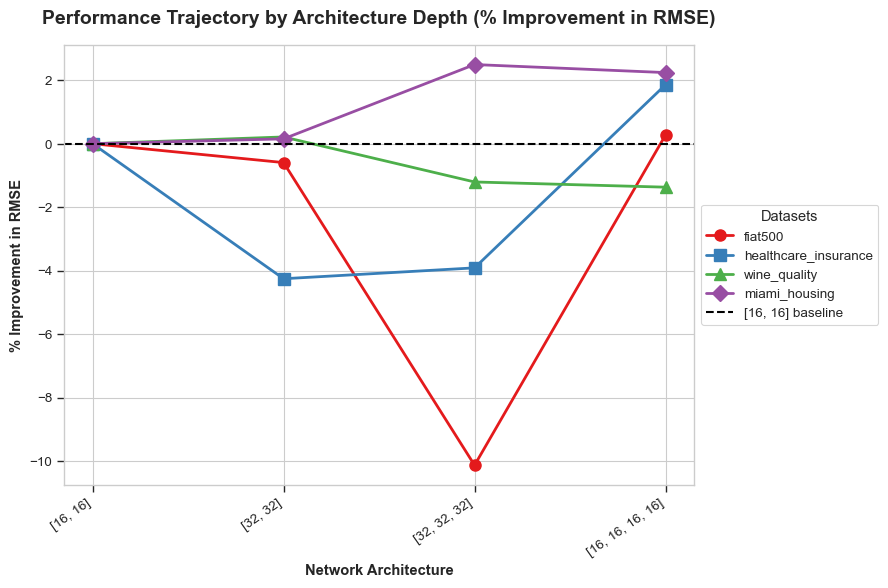

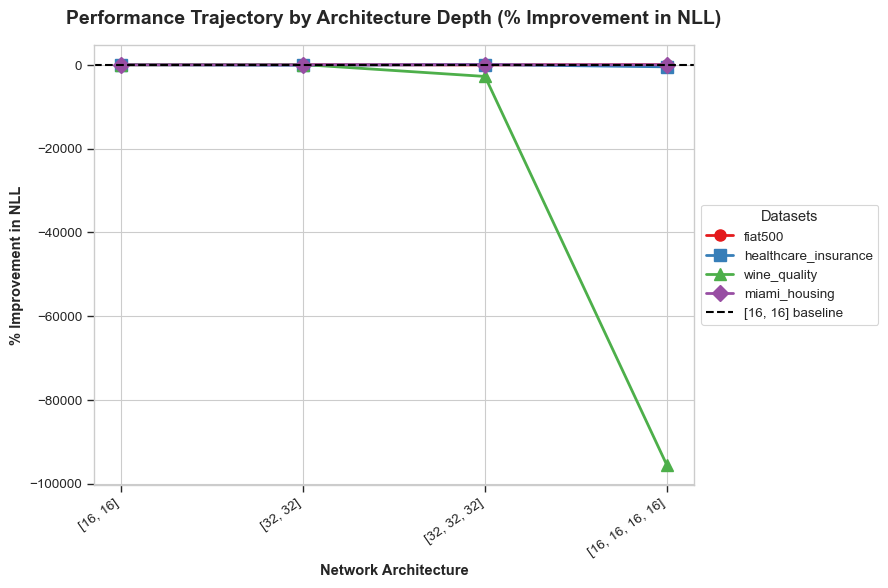

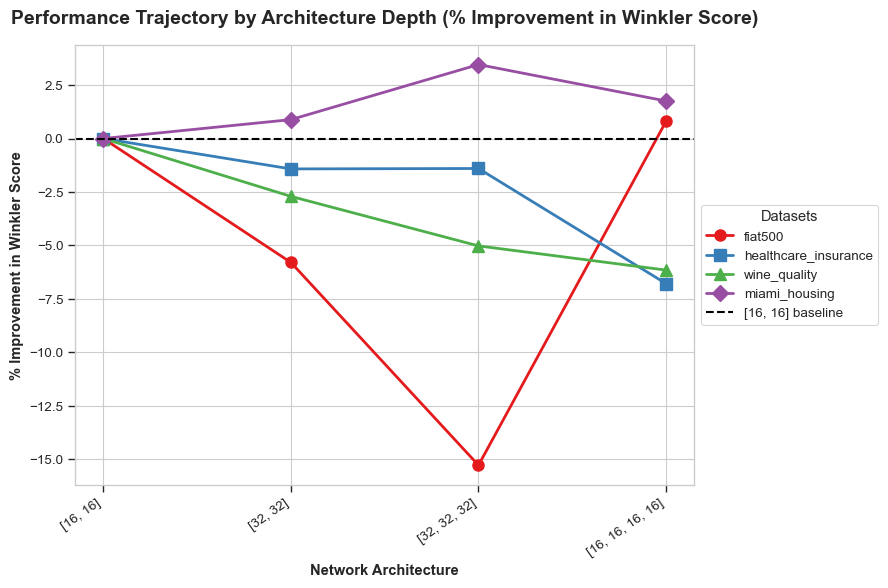

In [11]:
plot_metric_trajectory(trajectory_rmse, "RMSE", "trajectory_rmse.pdf")
plot_metric_trajectory(trajectory_nll, "NLL", "trajectory_nll.pdf")
plot_metric_trajectory(trajectory_winkler, "Winkler Score", "trajectory_winkler.pdf")

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.Orchestration.helpers import fetch_direct_child_runs

architectures = ["[16, 16]", "[32, 32]", "[32, 32, 32]", "[16, 16, 16, 16]"]
baseline_arch = "[16, 16]"

run_specs = [
    {
        "dataset": "fiat500",
        "experiment_id": "5",
        "run_id": "425666d19b9c4027a930589b8a6c63f1",
    },
    {
        "dataset": "healthcare_insurance",
        "experiment_id": "3",
        "run_id": "4a553a4264b54f3fb6b43216d4d7d444",
    },
    {
        "dataset": "wine_quality",
        "experiment_id": "4",
        "run_id": "c963c22d0c7b4f13a6ee0dc353b3ba1c",
    },
    {
        "dataset": "miami_housing",
        "experiment_id": "2",
        "run_id": "7e99f7fdc8a44f1b9461c3c1bdc6ec46",
    },
]

def build_metric_trajectory_df(run_specs, metric_col, architectures, baseline_arch, lower_is_better=True):
    rows = []

    for spec in run_specs:
        df, exp_name = fetch_direct_child_runs(
            experiment_id=spec["experiment_id"],
            run_id=spec["run_id"],
        )

        work = df[[
            "params.hidden_layers",
            metric_col,
        ]].copy()

        work = work.rename(columns={
            "params.hidden_layers": "architecture",
            metric_col: "metric_value",
        })

        work["architecture"] = work["architecture"].astype(str)
        work = work[work["architecture"].isin(architectures)]

        summary = (
            work.groupby("architecture", as_index=False)["metric_value"]
            .mean()
        )

        summary["architecture"] = pd.Categorical(
            summary["architecture"],
            categories=architectures,
            ordered=True,
        )
        summary = summary.sort_values("architecture")

        baseline_value = summary.loc[
            summary["architecture"] == baseline_arch, "metric_value"
        ].iloc[0]

        if lower_is_better:
            summary["improvement_pct"] = (
                (baseline_value - summary["metric_value"]) / abs(baseline_value)
            ) * 100
        else:
            summary["improvement_pct"] = (
                (summary["metric_value"] - baseline_value) / abs(baseline_value)
            ) * 100

        row = (
            summary.set_index("architecture")["improvement_pct"]
            .reindex(architectures)
            .rename(spec["dataset"])
        )
        rows.append(row)

    return pd.DataFrame(rows)

trajectory_rmse = build_metric_trajectory_df(
    run_specs,
    metric_col="metrics.RMSE",
    architectures=architectures,
    baseline_arch=baseline_arch,
    lower_is_better=True,
)

trajectory_nll = build_metric_trajectory_df(
    run_specs,
    metric_col="metrics.Negative_log_likelihood",
    architectures=architectures,
    baseline_arch=baseline_arch,
    lower_is_better=True,
)

trajectory_winkler = build_metric_trajectory_df(
    run_specs,
    metric_col="metrics.Mean_Winkler_Score",
    architectures=architectures,
    baseline_arch=baseline_arch,
    lower_is_better=True,
)






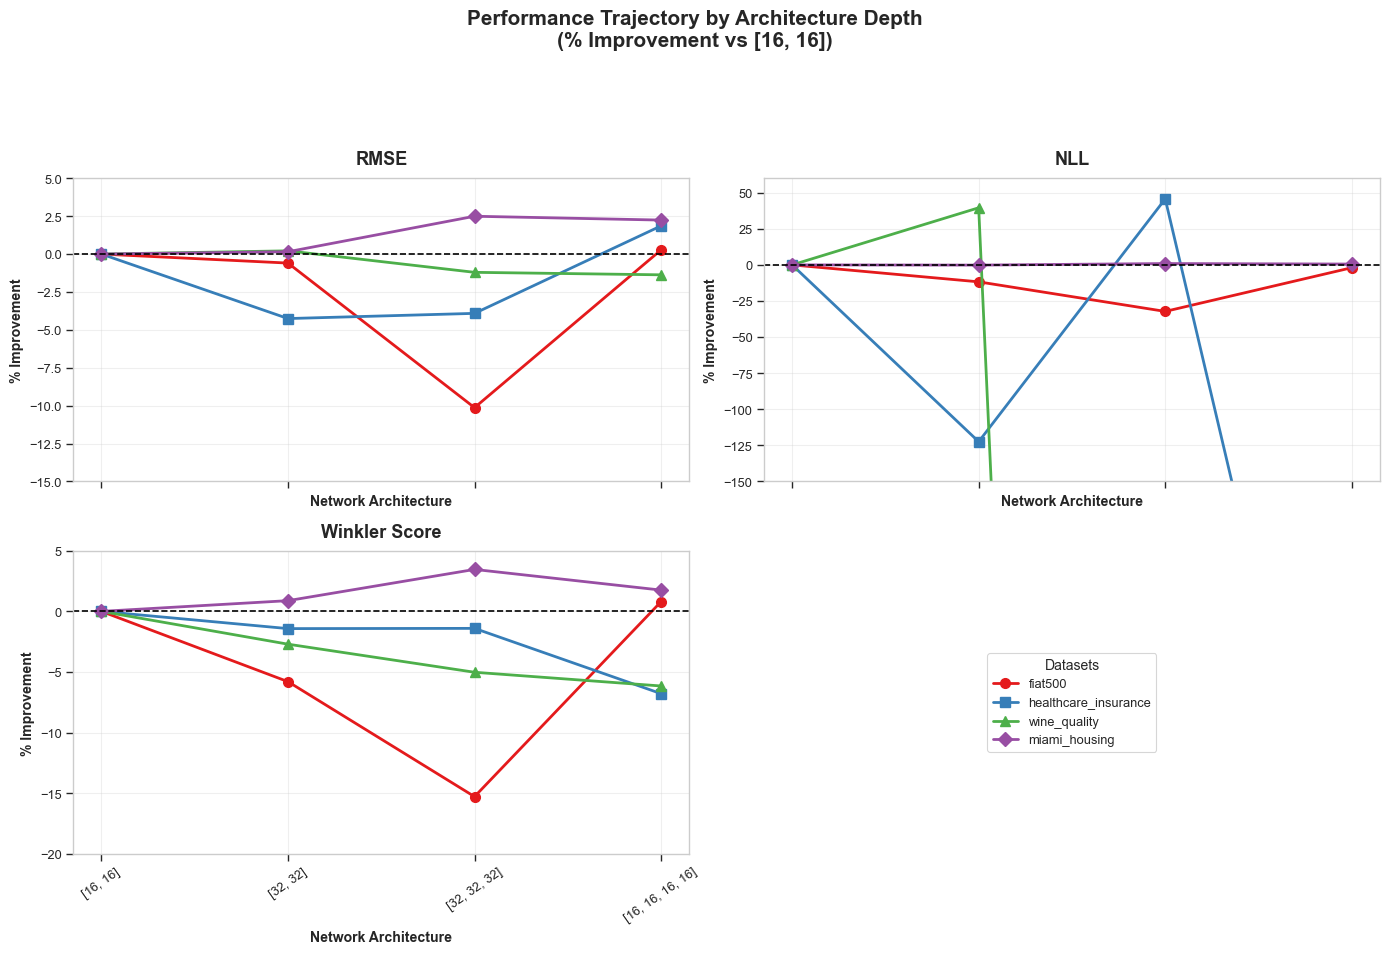

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("paper", font_scale=1.05)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=False)
axes = axes.flatten()

metric_plots = [
    ("RMSE", trajectory_rmse, axes[0]),
    ("NLL", trajectory_nll, axes[1]),
    ("Winkler Score", trajectory_winkler, axes[2]),
]

datasets = trajectory_rmse.index.tolist()
markers = ["o", "s", "^", "D"]
colors = sns.color_palette("Set1", len(datasets))

for metric_name, trajectory_df, ax in metric_plots:
    # 1. Plot the lines
    for idx, dataset_name in enumerate(datasets):
        ax.plot(
            architectures,
            trajectory_df.loc[dataset_name, architectures].values,
            marker=markers[idx % len(markers)],
            markersize=7,
            linewidth=2,
            label=dataset_name,
            color=colors[idx],
        )

    # 2. Add the baseline
    ax.axhline(0, color="black", linewidth=1.2, linestyle="--")
    
    # ==========================================
    # 3. THE FIX: Clip the Y-Axis Limits
    # ==========================================
    if metric_name == "RMSE":
        ax.set_ylim(-15, 5)    # Adjust bounds if your data goes slightly outside this
    elif metric_name == "NLL":
        ax.set_ylim(-150, 60)  # Clips the massive -95,000% outlier so the rest is visible!
    elif metric_name == "Winkler Score":
        ax.set_ylim(-20, 5)    # Adjust bounds if your data goes slightly outside this
    # ==========================================

    # 4. Standard Formatting
    ax.set_title(metric_name, fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("Network Architecture", fontweight="bold")
    ax.set_ylabel("% Improvement", fontweight="bold")
    ax.tick_params(axis="x", rotation=35)
    ax.grid(True, alpha=0.3)

# Shared Legend
legend_ax = axes[3]
legend_ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
legend_ax.legend(
    handles,
    labels,
    title="Datasets",
    loc="center",
    ncol=1,
    frameon=True,
)

fig.suptitle(
    "Performance Trajectory by Architecture Depth\n(% Improvement vs [16, 16])",
    fontsize=15,
    fontweight="bold",
    y=1.02,
)

plt.tight_layout(rect=[0, 0.07, 1, 0.95])
plt.savefig("trajectory_1x3_metrics.pdf", format="pdf", bbox_inches="tight")
plt.show()

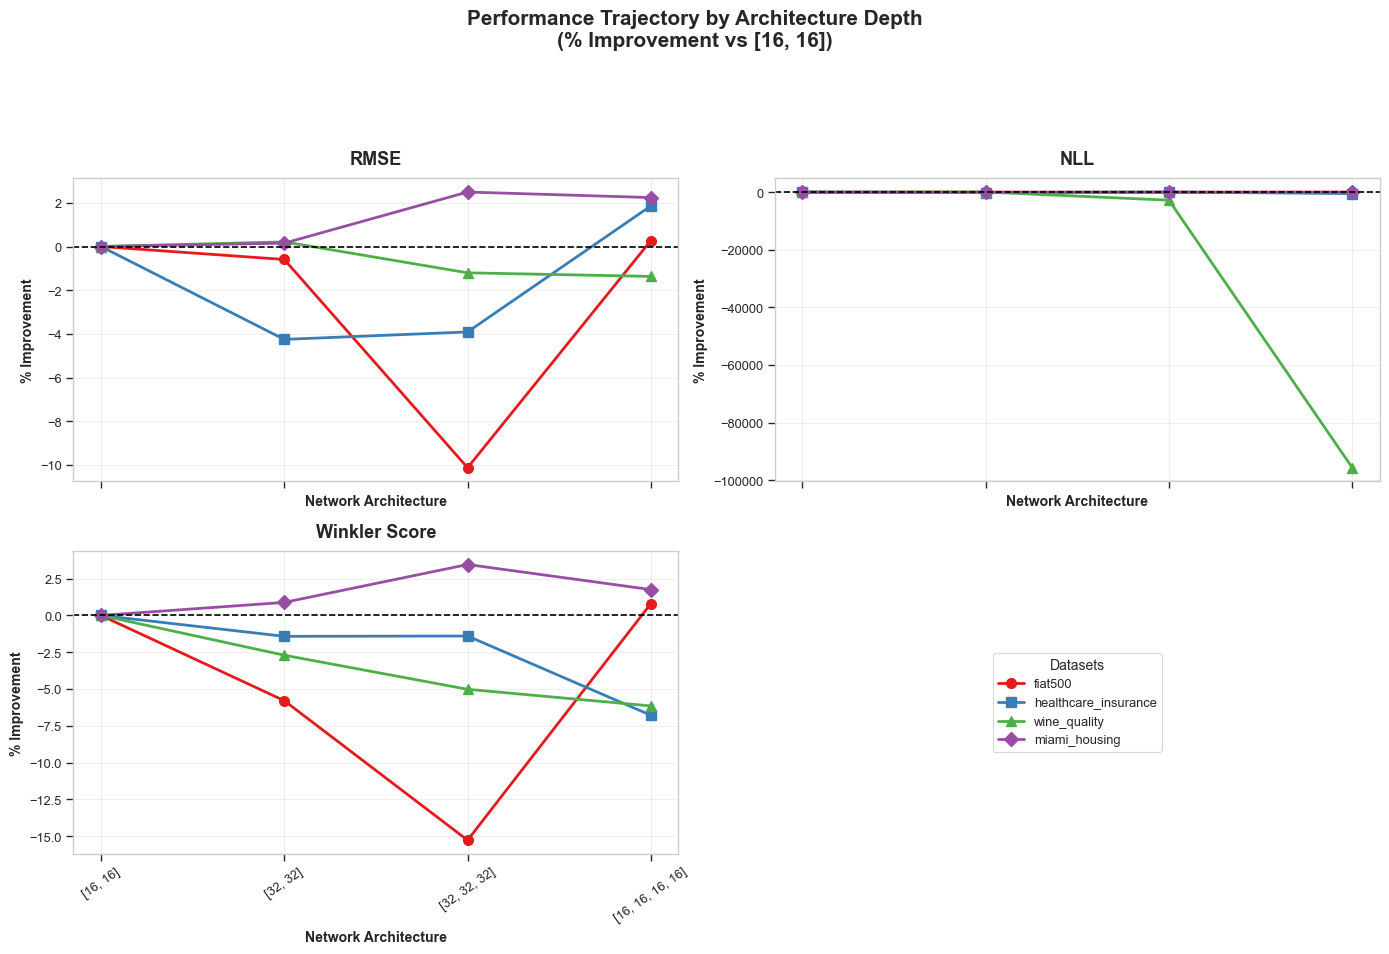

In [14]:
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("paper", font_scale=1.05)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=False)
axes = axes.flatten()

metric_plots = [
    ("RMSE", trajectory_rmse, axes[0]),
    ("NLL", trajectory_nll, axes[1]),
    ("Winkler Score", trajectory_winkler, axes[2]),
]

datasets = trajectory_rmse.index.tolist()
markers = ["o", "s", "^", "D"]
colors = sns.color_palette("Set1", len(datasets))

for metric_name, trajectory_df, ax in metric_plots:
    for idx, dataset_name in enumerate(datasets):
        ax.plot(
            architectures,
            trajectory_df.loc[dataset_name, architectures].values,
            marker=markers[idx % len(markers)],
            markersize=7,
            linewidth=2,
            label=dataset_name,
            color=colors[idx],
        )

    ax.axhline(0, color="black", linewidth=1.2, linestyle="--")
    ax.set_title(metric_name, fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("Network Architecture", fontweight="bold")
    ax.set_ylabel("% Improvement", fontweight="bold")
    ax.tick_params(axis="x", rotation=35)
    ax.grid(True, alpha=0.3)

legend_ax = axes[3]
legend_ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
legend_ax.legend(
    handles,
    labels,
    title="Datasets",
    loc="center",
    ncol=1,
    frameon=True,
)

fig.suptitle(
    "Performance Trajectory by Architecture Depth\n(% Improvement vs [16, 16])",
    fontsize=15,
    fontweight="bold",
    y=1.02,
)

plt.tight_layout(rect=[0, 0.07, 1, 0.95])
plt.savefig("trajectory_1x3_metrics.pdf", format="pdf", bbox_inches="tight")
plt.show()

#### trajectory best config , positive % means better, so lower value

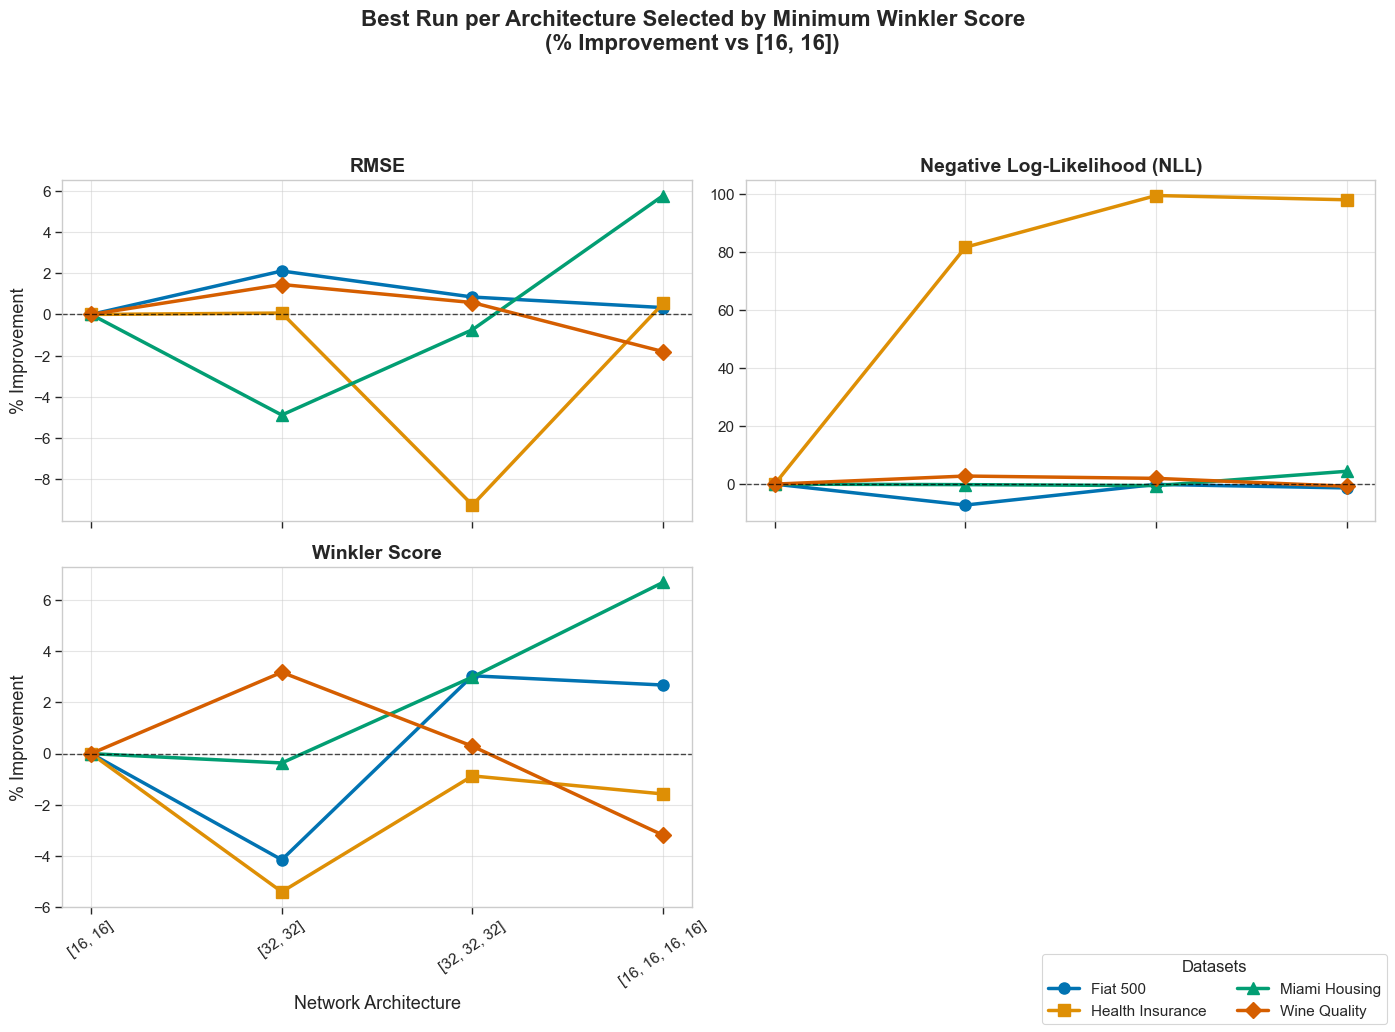

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.Orchestration.helpers import fetch_direct_child_runs

architectures = ["[16, 16]", "[32, 32]", "[32, 32, 32]", "[16, 16, 16, 16]"]
baseline_arch = "[16, 16]"

run_specs = [
    {
        "dataset": "fiat500",
        "experiment_id": "5",
        "run_id": "425666d19b9c4027a930589b8a6c63f1",
    },
    {
        "dataset": "healthcare_insurance",
        "experiment_id": "3",
        "run_id": "4a553a4264b54f3fb6b43216d4d7d444",
    },
    {
        "dataset": "wine_quality",
        "experiment_id": "4",
        "run_id": "c963c22d0c7b4f13a6ee0dc353b3ba1c",
    },
    {
        "dataset": "miami_housing",
        "experiment_id": "2",
        "run_id": "7e99f7fdc8a44f1b9461c3c1bdc6ec46",
    },
]


def build_best_per_architecture_df(run_specs, architectures):
    rows = []

    for spec in run_specs:
        df, exp_name = fetch_direct_child_runs(
            experiment_id=spec["experiment_id"],
            run_id=spec["run_id"],
        )

        work = df[[
            "run_id",
            "params.hidden_layers",
            "metrics.RMSE",
            "metrics.Negative_log_likelihood",
            "metrics.Mean_Winkler_Score",
        ]].copy()

        work = work.rename(columns={
            "params.hidden_layers": "architecture",
            "metrics.RMSE": "rmse",
            "metrics.Negative_log_likelihood": "nll",
            "metrics.Mean_Winkler_Score": "winkler",
        })

        work["architecture"] = work["architecture"].astype(str)
        work = work[work["architecture"].isin(architectures)]

        best_idx = work.groupby("architecture")["winkler"].idxmin()
        best_rows = work.loc[best_idx].copy()

        best_rows["architecture"] = pd.Categorical(
            best_rows["architecture"],
            categories=architectures,
            ordered=True,
        )
        best_rows = best_rows.sort_values("architecture")
        best_rows["dataset"] = spec["dataset"]

        rows.append(best_rows)

    return pd.concat(rows, ignore_index=True)


best_runs_df = build_best_per_architecture_df(run_specs, architectures)


def build_metric_trajectory_from_best(best_runs_df, metric_col, baseline_arch, lower_is_better=True):
    result_rows = []

    for dataset_name, group in best_runs_df.groupby("dataset"):
        group = group.copy()

        baseline_value = group.loc[
            group["architecture"] == baseline_arch, metric_col
        ].iloc[0]

        if lower_is_better:
            group["improvement_pct"] = (
                (baseline_value - group[metric_col]) / abs(baseline_value)
            ) * 100
        else:
            group["improvement_pct"] = (
                (group[metric_col] - baseline_value) / abs(baseline_value)
            ) * 100

        row = (
            group.set_index("architecture")["improvement_pct"]
            .reindex(architectures)
            .rename(dataset_name)
        )
        result_rows.append(row)

    return pd.DataFrame(result_rows)


trajectory_rmse = build_metric_trajectory_from_best(
    best_runs_df, metric_col="rmse", baseline_arch=baseline_arch, lower_is_better=True
)

trajectory_nll = build_metric_trajectory_from_best(
    best_runs_df, metric_col="nll", baseline_arch=baseline_arch, lower_is_better=True
)

trajectory_winkler = build_metric_trajectory_from_best(
    best_runs_df, metric_col="winkler", baseline_arch=baseline_arch, lower_is_better=True
)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("paper", font_scale=1.2)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=False)
axes = axes.flatten()

metric_plots = [
    ("RMSE", trajectory_rmse, axes[0]),
    ("Negative Log-Likelihood (NLL)", trajectory_nll, axes[1]),
    ("Winkler Score", trajectory_winkler, axes[2]),
]

dataset_labels = {
    "fiat500": "Fiat 500",
    "healthcare_insurance": "Health Insurance",
    "miami_housing": "Miami Housing",
    "wine_quality": "Wine Quality",
}

palette = sns.color_palette("colorblind", 4)
dataset_colors = {
    "fiat500": palette[0],
    "healthcare_insurance": palette[1],
    "miami_housing": palette[2],
    "wine_quality": palette[3],
}

dataset_markers = {
    "fiat500": "o",
    "healthcare_insurance": "s",
    "miami_housing": "^",
    "wine_quality": "D",
}

datasets = trajectory_rmse.index.tolist()

for plot_idx, (metric_name, trajectory_df, ax) in enumerate(metric_plots):
    for dataset_name in datasets:
        ax.plot(
            architectures,
            trajectory_df.loc[dataset_name, architectures].values,
            marker=dataset_markers[dataset_name],
            markersize=8,
            linewidth=2.5,
            label=dataset_labels[dataset_name],
            color=dataset_colors[dataset_name],
        )

    ax.set_title(metric_name, fontsize=14, fontweight="bold")
    ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.7)

    ax.set_title(metric_name, fontsize=14, fontweight="bold")

    if plot_idx in (0, 2):
        ax.set_ylabel("% Improvement", fontsize=13)
    else:
        ax.set_ylabel("")

    if plot_idx == 2:
        ax.set_xlabel("Network Architecture", fontsize=13)
    else:
        ax.set_xlabel("")

    ax.tick_params(axis="x", rotation=35, labelsize=11)
    ax.tick_params(axis="y", labelsize=11)
    ax.grid(True, alpha=0.5)
legend_ax = axes[3]
legend_ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Datasets",
    loc="lower right",
    ncol=2,
    frameon=True,
    fancybox=True,
    shadow=False,
    fontsize=11,
    title_fontsize=12,
)

fig.suptitle(
    "Best Run per Architecture Selected by Minimum Winkler Score\n(% Improvement vs [16, 16])",
    fontsize=16,
    fontweight="bold",
    y=1.02,
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("trajectory_best_per_architecture_2x2.pdf", format="pdf", bbox_inches="tight")
plt.show()